In [19]:
import numpy as np
import json
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import os
from sklearn.decomposition import PCA

In [37]:
# Setting up path variables
PATH_output_dir = "/home/ppathak2/Hypothesis_Generation_Active_Learning/output_trees"
domain = 'material science'
topic = 'heat coefficient_r5'
PATH_contex_forest = os.path.join(PATH_output_dir, domain, topic)
os.path.isdir(PATH_contex_forest)

True

In [38]:
## Load a json tree-

tree_name = 'run_1'
PATH_tree = os.path.join(PATH_contex_forest, tree_name, 'embdng_tree.json')
with open(PATH_tree, 'r') as f:
    emdng_context_tree = json.load(f)

In [39]:
def polar_normalization(vec:np.ndarray):
    min_val = np.min(vec)
    max_val = np.max(vec)
    
    if max_val == min_val:
        return np.zeros_like(vec)
    
    scaled = (vec - min_val) / (max_val - min_val)
    normalized = scaled * 2 - 1
    return normalized

==========  heat coefficient  ==========
Depth: 1
# instances: 1
==========  thermal conductivity  ==========
Depth: 2
# instances: 3


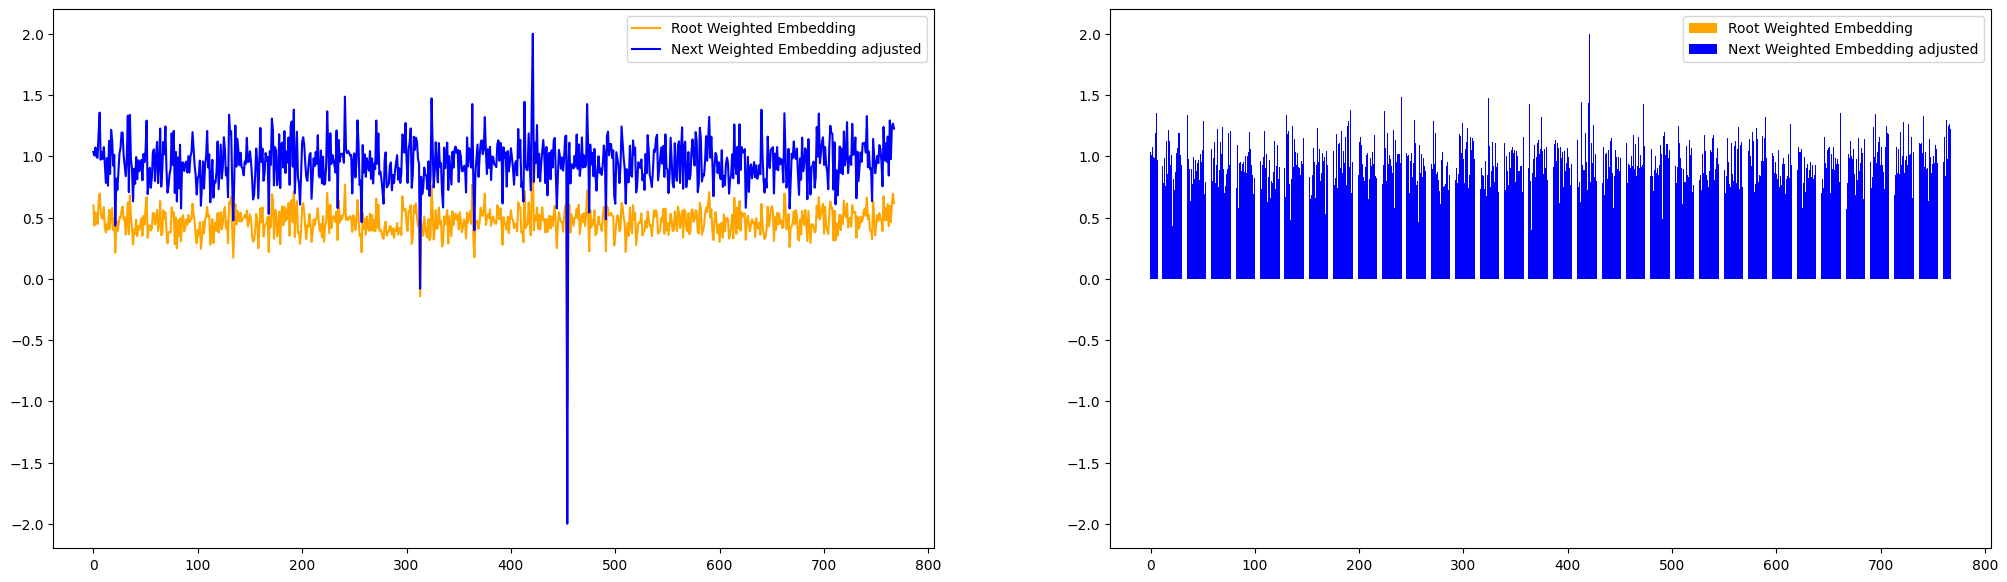

In [40]:
# Plotting the intial embedding of root keyword and then adding the first child weighted averaging-

root_keyword = next(iter(emdng_context_tree))

root_depth, root_occurances = emdng_context_tree[root_keyword]['data'][:-1]
root_weighted_emdng = np.array(emdng_context_tree[root_keyword]['w88_enc'])

print("="*10, f" {root_keyword} ", "="*10)
print(f"Depth: {root_depth}")
print(f"# instances: {root_occurances}")
print("="*50)

next_keyword = 'thermal conductivity'
next_depth, next_occurances = emdng_context_tree[next_keyword]['data'][:-1]
next_weighted_emdng = np.array(emdng_context_tree[next_keyword]['w88_enc'])

print("="*10, f" {next_keyword} ", "="*10)
print(f"Depth: {next_depth}")
print(f"# instances: {next_occurances}")
print("="*50)

x_root_weighted_emdng = np.array(range(len(root_weighted_emdng)))
y_root_weighted_emdng = polar_normalization(root_weighted_emdng)

x_next_weighted_emdng = np.array(range(len(next_weighted_emdng)))
y_next_weighted_emdng = polar_normalization(next_weighted_emdng) + y_root_weighted_emdng

fig, axs = plt.subplots(1, 2, figsize=(25, 7))
axs[0].plot(x_root_weighted_emdng, y_root_weighted_emdng, color='orange', label='Root Weighted Embedding')
axs[0].plot(x_next_weighted_emdng, y_next_weighted_emdng, color='blue', label='Next Weighted Embedding adjusted')
axs[0].legend()

axs[1].bar(x_root_weighted_emdng, y_root_weighted_emdng, color='orange', label='Root Weighted Embedding')
axs[1].bar(x_next_weighted_emdng, y_next_weighted_emdng, color='blue', label='Next Weighted Embedding adjusted')
axs[1].legend()


plt.show()

# dispersion analysis-

In [56]:
def calculate_context_embedding(context_tree_embd:dict, normalize:bool=True):

    final_embedding = np.zeros_like(context_tree_embd[next(iter(context_tree_embd))]['w88_enc'])
    for keyword, values in context_tree_embd.items():
        w88_embding = np.array(values['w88_enc'])
        if (np.isnan(w88_embding).any() or np.isinf(w88_embding).any()):
            continue
        if normalize:
            w88_embding = polar_normalization(w88_embding)
        final_embedding += w88_embding

    return final_embedding

In [70]:
raw_embedding_space = np.random.rand(len(os.listdir(PATH_contex_forest)), 768)
for i, run_num in enumerate(os.listdir(PATH_contex_forest)):
    PATH_tree = os.path.join(PATH_contex_forest, run_num, 'embdng_tree.json')
    with open(PATH_tree, 'r') as f:
        emdng_context_tree = json.load(f)

    final_embedding = calculate_context_embedding(emdng_context_tree, normalize=False)
    raw_embedding_space[i, :] = final_embedding
raw_embedding_space.shape

(7, 768)

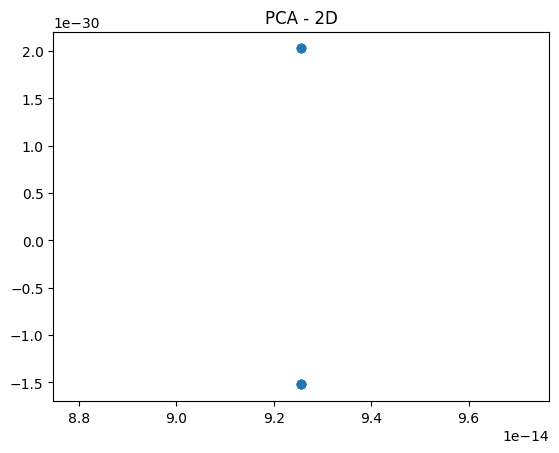

In [71]:
# 2D PCA analysis and plotting-
pca_2d = PCA(n_components=2)
reduced_2d = pca_2d.fit_transform(raw_embedding_space)


plt.figure()
plt.scatter(reduced_2d[:, 0], reduced_2d[:, 1])
plt.title("PCA - 2D")
plt.show()

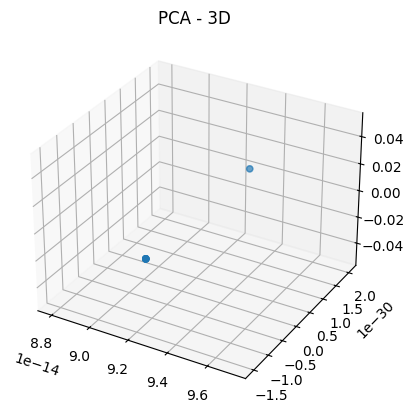

In [72]:
pca_3d = PCA(n_components=3)
reduced_3d = pca_3d.fit_transform(raw_embedding_space)
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(reduced_3d[:, 0], reduced_3d[:, 1], reduced_3d[:, 2])
ax.set_title("PCA - 3D")
plt.show()

In [77]:
# Calculating dispersion std, and std accross dimensions-
centroid = np.mean(raw_embedding_space, axis=0)

distances = np.linalg.norm(raw_embedding_space - centroid, axis=1)
dispersion = np.mean(distances)

print(f"Dispersion: {dispersion}")

std_dev = np.std(raw_embedding_space)
print(f"Standard Deviation of Raw Embeddings: {std_dev}")

Dispersion: 9.256496535445951e-14
Standard Deviation of Raw Embeddings: 20.397820502872268
